In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import Counter

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

C:\Users\Apoorv Bagga\AppData\Roaming\Python\Python310\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


✅ Using device: cuda


---
## 📄 Step 1: Define the Dataset

In [2]:
# Lab-provided dataset
corpus = """
artificial intelligence systems learn patterns from data.
sequence models process information step by step.
recurrent neural networks are useful for sequence prediction.
lstm networks handle long term dependencies.
deep learning models improve sequence learning.
generative models create new samples from learned patterns.
language models predict the next word in a sentence.
sequence generation is used in chatbots and assistants.
machine learning helps computers learn automatically.
training data improves model accuracy.
neural networks simulate human brain structures.
optimization algorithms improve learning efficiency.
technology is transforming modern education.
online learning platforms use artificial intelligence.
students benefit from intelligent tutoring systems.
automation improves productivity and decision making.
""".strip()

print("📋 Dataset loaded successfully!")
print(f"Total characters : {len(corpus)}")
print(f"Total words      : {len(corpus.split())}")
print(f"Total sentences  : {len(corpus.splitlines())}")

📋 Dataset loaded successfully!
Total characters : 832
Total words      : 104
Total sentences  : 16


---
# 🔷 COMPONENT I: RNN / LSTM Based Sequential Data Generation

## Task 1 & 2: Preprocessing & Character-Level Tokenization

In [3]:
# ─── Character-level tokenization ───────────────────────────────────────────
text = corpus.lower()

# Build vocabulary from unique characters
chars      = sorted(set(text))
vocab_size = len(chars)

# Create mappings: character ↔ index
char2idx = {ch: idx for idx, ch in enumerate(chars)}
idx2char = {idx: ch  for idx, ch in enumerate(chars)}

# Encode entire corpus as integer indices
encoded = [char2idx[ch] for ch in text]

print(f"Vocabulary size : {vocab_size}")
print(f"Unique characters: {''.join(chars)}")
print(f"Encoded length  : {len(encoded)}")
print(f"Sample encoding : '{text[:20]}' → {encoded[:20]}")

Vocabulary size : 28
Unique characters: 
 .abcdefghiklmnopqrstuvwxyz
Encoded length  : 832
Sample encoding : 'artificial intellige' → [3, 19, 21, 11, 8, 11, 5, 11, 3, 13, 1, 11, 15, 21, 7, 13, 13, 11, 9, 7]


## Task 3: Create Input-Output Sequence Pairs

In [4]:
# ─── Create overlapping sequences of fixed length ──────────────────────────
SEQ_LEN = 40   # number of characters per input sequence

sequences = []   # input sequences
targets   = []   # next-character targets

for i in range(0, len(encoded) - SEQ_LEN):
    sequences.append(encoded[i : i + SEQ_LEN])
    targets.append(encoded[i + SEQ_LEN])

# Convert to PyTorch tensors
X_rnn = torch.tensor(sequences, dtype=torch.long).to(device)
y_rnn = torch.tensor(targets,   dtype=torch.long).to(device)

print(f"Total training samples : {len(sequences)}")
print(f"Input shape            : {X_rnn.shape}")
print(f"Target shape           : {y_rnn.shape}")
print(f"\nExample input  : {sequences[0]}")
print(f"Example target : {targets[0]} → '{idx2char[targets[0]]}'")

Total training samples : 792
Input shape            : torch.Size([792, 40])
Target shape           : torch.Size([792])

Example input  : [3, 19, 21, 11, 8, 11, 5, 11, 3, 13, 1, 11, 15, 21, 7, 13, 13, 11, 9, 7, 15, 5, 7, 1, 20, 26, 20, 21, 7, 14, 20, 1, 13, 7, 3, 19, 15, 1, 17, 3]
Example target : 21 → 't'


## Task 4: Design the LSTM-Based Generative Model

In [5]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM language model.
    Architecture:
        Embedding → LSTM (stacked) → Dropout → Fully Connected → Softmax
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super(CharLSTM, self).__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers

        # Embedding layer: maps character indices → dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM: learns sequential patterns
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        # Output layer: maps hidden state → vocabulary logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))      # (batch, seq_len, embed_dim)
        out, hidden = self.lstm(emb, hidden)        # (batch, seq_len, hidden_dim)
        out = self.dropout(out[:, -1, :])           # take last timestep
        logits = self.fc(out)                       # (batch, vocab_size)
        return logits, hidden

# ─── Hyperparameters ────────────────────────────────────────────────────────
EMBED_DIM  = 64
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.3

lstm_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)

# Count parameters
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f"\n✅ Total trainable parameters: {total_params:,}")

CharLSTM(
  (embedding): Embedding(28, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=28, bias=True)
)

✅ Total trainable parameters: 865,052


## Task 5: Train the LSTM Model

In [6]:
# ─── Training Setup ─────────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 80
LEARNING_RATE = 0.003

criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler   = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Build mini-batches
dataset = torch.utils.data.TensorDataset(X_rnn, y_rnn)
loader  = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

lstm_losses = []

print("🚀 Starting LSTM Training...")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    epoch_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()
        logits, _ = lstm_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    lstm_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}  LR: {scheduler.get_last_lr()[0]:.5f}")

print("-" * 50)
print("✅ LSTM Training Complete!")

🚀 Starting LSTM Training...
--------------------------------------------------
Epoch [ 10/80]  Loss: 1.0186  LR: 0.00300
Epoch [ 20/80]  Loss: 0.2074  LR: 0.00300
Epoch [ 30/80]  Loss: 0.0926  LR: 0.00150
Epoch [ 40/80]  Loss: 0.0410  LR: 0.00150
Epoch [ 50/80]  Loss: 0.0227  LR: 0.00150
Epoch [ 60/80]  Loss: 0.0208  LR: 0.00075
Epoch [ 70/80]  Loss: 0.0098  LR: 0.00075
Epoch [ 80/80]  Loss: 0.0078  LR: 0.00075
--------------------------------------------------
✅ LSTM Training Complete!


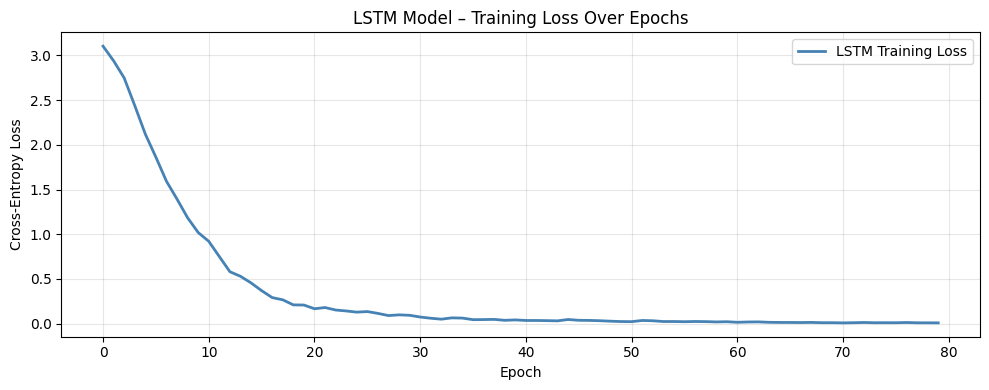

In [7]:
# ─── Plot Training Loss ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(lstm_losses, color='steelblue', linewidth=2, label='LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('LSTM Model – Training Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 6: Generate New Sequences Using a Seed Input

In [8]:
def generate_text_lstm(model, seed_text, length=200, temperature=0.8):
    """
    Generate text using the trained LSTM model.

    Args:
        model       : Trained CharLSTM model
        seed_text   : Starting string to condition the model
        length      : Number of new characters to generate
        temperature : Sampling temperature
                      (< 1 = more conservative, > 1 = more creative)
    Returns:
        Generated string
    """
    model.eval()
    seed_text = seed_text.lower()

    # Encode seed, handling unknown characters
    seed_encoded = [char2idx.get(ch, 0) for ch in seed_text[-SEQ_LEN:]]

    # Pad if seed is shorter than SEQ_LEN
    if len(seed_encoded) < SEQ_LEN:
        seed_encoded = [0] * (SEQ_LEN - len(seed_encoded)) + seed_encoded

    generated = seed_text
    current_seq = seed_encoded[:]

    with torch.no_grad():
        for _ in range(length):
            x = torch.tensor([current_seq], dtype=torch.long).to(device)
            logits, _ = model(x)

            # Apply temperature scaling
            probs = torch.softmax(logits[0] / temperature, dim=0).cpu().numpy()

            # Sample from distribution
            next_idx = np.random.choice(len(probs), p=probs)
            next_char = idx2char[next_idx]

            generated += next_char
            current_seq = current_seq[1:] + [next_idx]

    return generated


# ─── Generate with different seeds and temperatures ─────────────────────────
seeds = [
    ("neural networks",    0.6),
    ("deep learning",      0.8),
    ("sequence models",    1.0),
]

print("=" * 65)
print("         🤖 LSTM – GENERATED TEXT SEQUENCES")
print("=" * 65)

for seed, temp in seeds:
    output = generate_text_lstm(lstm_model, seed, length=150, temperature=temp)
    print(f"\n📌 Seed       : '{seed}'")
    print(f"   Temperature: {temp}")
    print(f"   Output     :\n")
    print(f"   {output}")
    print("-" * 65)

         🤖 LSTM – GENERATED TEXT SEQUENCES

📌 Seed       : 'neural networks'
   Temperature: 0.6
   Output     :

   neural networks are useful for sequence prediction.
lstm networks handle long term dependencies.
deep learning models improve sequence learning.
generative models cr
-----------------------------------------------------------------

📌 Seed       : 'deep learning'
   Temperature: 0.8
   Output     :

   deep learning models improve sequence learning.
generative models create new samples from learned patterns.
language models predict the next word in a sentence.
se
-----------------------------------------------------------------

📌 Seed       : 'sequence models'
   Temperature: 1.0
   Output     :

   sequence models process information step by step.
recurrent neural networks are useful for sequence prediction.
lstm networks handle long term dependencies.
deep lea
-----------------------------------------------------------------


---
# 🔶 COMPONENT II: Transformer Based Sequential Data Generation

## Task 1 & 2: Dataset + Word-Level Tokenization

In [9]:
import re

# ─── Word-level tokenization ────────────────────────────────────────────────
def tokenize(text):
    """Lowercase, strip punctuation except periods, split on whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\.\s]', '', text)
    return text.split()

# Build word-level token list
words = tokenize(corpus)

# Build vocabulary with special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

word_counts = Counter(words)
vocab_words = [PAD_TOKEN, UNK_TOKEN] + sorted(word_counts.keys())

word2idx_t = {w: i for i, w in enumerate(vocab_words)}
idx2word_t = {i: w for i, w in enumerate(vocab_words)}

vocab_size_t = len(vocab_words)

# Encode the corpus
encoded_words = [word2idx_t.get(w, 1) for w in words]

print(f"Word vocabulary size : {vocab_size_t}")
print(f"Total tokens         : {len(encoded_words)}")
print(f"Vocabulary sample    : {vocab_words[2:15]}")

Word vocabulary size : 85
Total tokens         : 104
Vocabulary sample    : ['a', 'accuracy.', 'algorithms', 'and', 'are', 'artificial', 'assistants.', 'automatically.', 'automation', 'benefit', 'brain', 'by', 'chatbots']


In [10]:
# ─── Create word-level sequence pairs ───────────────────────────────────────
SEQ_LEN_T = 8    # words per input sequence

seq_inputs  = []
seq_targets = []

for i in range(len(encoded_words) - SEQ_LEN_T):
    seq_inputs.append(encoded_words[i : i + SEQ_LEN_T])
    seq_targets.append(encoded_words[i + SEQ_LEN_T])

X_tr = torch.tensor(seq_inputs,  dtype=torch.long).to(device)
y_tr = torch.tensor(seq_targets, dtype=torch.long).to(device)

print(f"Transformer training samples : {len(seq_inputs)}")
print(f"Input shape                  : {X_tr.shape}")
print(f"Target shape                 : {y_tr.shape}")

Transformer training samples : 96
Input shape                  : torch.Size([96, 8])
Target shape                 : torch.Size([96])


## Task 3: Positional Encoding

In [11]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding as introduced in 'Attention Is All You Need'.

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    This injects position information into the token embeddings so the
    Transformer can reason about sequence order.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)

        # Build positional encoding matrix
        pe = torch.zeros(max_len, d_model)                       # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float() # (max_len, 1)

        # Compute division term using log-space for numerical stability
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)   # odd dimensions

        pe = pe.unsqueeze(0)   # (1, max_len, d_model) → broadcast over batch
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print("✅ PositionalEncoding defined.")

# Quick sanity check
pe_test = PositionalEncoding(d_model=64, max_len=100)
dummy   = torch.zeros(2, 10, 64)   # batch=2, seq=10, d_model=64
out     = pe_test(dummy)
print(f"   Input shape  : {dummy.shape}")
print(f"   Output shape : {out.shape}")

✅ PositionalEncoding defined.
   Input shape  : torch.Size([2, 10, 64])
   Output shape : torch.Size([2, 10, 64])


## Task 4: Design the Transformer Encoder Model

In [12]:
class TransformerTextGenerator(nn.Module):
    """
    Transformer Encoder-based language model for sequence generation.

    Architecture:
        Token Embedding
            ↓
        Positional Encoding
            ↓
        Transformer Encoder Layers  (Multi-Head Self-Attention + FFN)
            ↓
        Global Average Pooling (over sequence dimension)
            ↓
        Fully Connected → Vocabulary Logits
    """
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers,
                 dim_feedforward, dropout, max_seq_len):
        super(TransformerTextGenerator, self).__init__()

        self.d_model = d_model

        # Token embedding layer
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_seq_len, dropout=dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True   # (batch, seq, feature) format
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

        self.dropout = nn.Dropout(dropout)

        # Output projection
        self.fc_out = nn.Linear(d_model, vocab_size)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Xavier uniform initialization for linear layers."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.01)

    def forward(self, x, src_key_padding_mask=None):
        # x: (batch, seq_len)
        emb = self.embedding(x) * math.sqrt(self.d_model)   # scale embeddings
        emb = self.pos_encoding(emb)                         # add positional info

        # Transformer encoder: captures global context via self-attention
        enc_out = self.transformer_encoder(
            emb,
            src_key_padding_mask=src_key_padding_mask
        )   # (batch, seq_len, d_model)

        # Global average pooling over sequence dimension
        pooled = enc_out.mean(dim=1)   # (batch, d_model)
        pooled = self.dropout(pooled)

        # Project to vocabulary
        logits = self.fc_out(pooled)   # (batch, vocab_size)
        return logits


# ─── Transformer Hyperparameters ────────────────────────────────────────────
D_MODEL         = 64      # embedding / model dimension
NHEAD           = 4       # number of attention heads (D_MODEL must be divisible)
NUM_ENC_LAYERS  = 3       # stacked encoder layers
DIM_FEEDFORWARD = 256     # inner FFN dimension
DROPOUT_T       = 0.2
MAX_SEQ_LEN     = 512

transformer_model = TransformerTextGenerator(
    vocab_size      = vocab_size_t,
    d_model         = D_MODEL,
    nhead           = NHEAD,
    num_encoder_layers = NUM_ENC_LAYERS,
    dim_feedforward = DIM_FEEDFORWARD,
    dropout         = DROPOUT_T,
    max_seq_len     = MAX_SEQ_LEN
).to(device)

total_params_t = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(transformer_model)
print(f"\n✅ Total trainable parameters: {total_params_t:,}")

TransformerTextGenerator(
  (embedding): Embedding(85, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_out): Linear(in_features=64, out_features=85, bias=True)
)

✅ Total trainable p

## Task 5: Train the Transformer Model

In [13]:
# ─── Training Setup ─────────────────────────────────────────────────────────
BATCH_SIZE_T  = 32
EPOCHS_T      = 100
LR_T          = 0.001
WARMUP_STEPS  = 20

criterion_t  = nn.CrossEntropyLoss(ignore_index=0)
optimizer_t  = optim.Adam(transformer_model.parameters(), lr=LR_T, betas=(0.9, 0.98), eps=1e-9)

# Cosine annealing scheduler
scheduler_t = optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=EPOCHS_T, eta_min=1e-5)

dataset_t = torch.utils.data.TensorDataset(X_tr, y_tr)
loader_t  = torch.utils.data.DataLoader(dataset_t, batch_size=BATCH_SIZE_T, shuffle=True)

transformer_losses = []

print("🚀 Starting Transformer Training...")
print("-" * 50)

for epoch in range(1, EPOCHS_T + 1):
    transformer_model.train()
    epoch_loss = 0.0

    for xb, yb in loader_t:
        optimizer_t.zero_grad()

        # Build padding mask: True where token == PAD
        pad_mask = (xb == 0).to(device)

        logits = transformer_model(xb, src_key_padding_mask=pad_mask)
        loss   = criterion_t(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer_t.step()
        epoch_loss += loss.item()

    scheduler_t.step()
    avg_loss = epoch_loss / len(loader_t)
    transformer_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{EPOCHS_T}]  Loss: {avg_loss:.4f}  LR: {scheduler_t.get_last_lr()[0]:.6f}")

print("-" * 50)
print("✅ Transformer Training Complete!")

🚀 Starting Transformer Training...
--------------------------------------------------
Epoch [ 10/100]  Loss: 4.3216  LR: 0.000976
Epoch [ 20/100]  Loss: 3.4410  LR: 0.000905
Epoch [ 30/100]  Loss: 2.8039  LR: 0.000796
Epoch [ 40/100]  Loss: 2.4240  LR: 0.000658
Epoch [ 50/100]  Loss: 2.1987  LR: 0.000505
Epoch [ 60/100]  Loss: 1.9415  LR: 0.000352
Epoch [ 70/100]  Loss: 1.8001  LR: 0.000214
Epoch [ 80/100]  Loss: 1.7084  LR: 0.000105
Epoch [ 90/100]  Loss: 1.6884  LR: 0.000034
Epoch [100/100]  Loss: 1.6422  LR: 0.000010
--------------------------------------------------
✅ Transformer Training Complete!


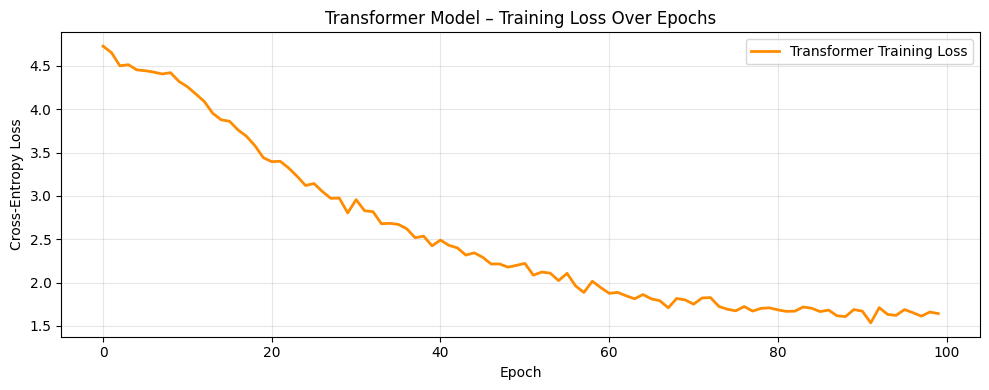

In [14]:
# ─── Plot Training Loss ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(transformer_losses, color='darkorange', linewidth=2, label='Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer Model – Training Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 6: Generate New Sequences Using the Transformer

In [15]:
def generate_text_transformer(model, seed_words, num_words=20, temperature=0.8, top_k=10):
    """
    Generate a word sequence using the trained Transformer model.

    Args:
        model       : Trained TransformerTextGenerator
        seed_words  : List of seed words to start generation
        num_words   : Number of words to generate
        temperature : Sampling temperature
        top_k       : Top-K sampling (0 = full distribution)
    Returns:
        Generated sentence as a string
    """
    model.eval()

    # Encode seed words
    current_tokens = [word2idx_t.get(w.lower(), 1) for w in seed_words]

    # Pad or trim to SEQ_LEN_T
    if len(current_tokens) < SEQ_LEN_T:
        current_tokens = [0] * (SEQ_LEN_T - len(current_tokens)) + current_tokens
    else:
        current_tokens = current_tokens[-SEQ_LEN_T:]

    generated_words = list(seed_words)

    with torch.no_grad():
        for _ in range(num_words):
            x        = torch.tensor([current_tokens], dtype=torch.long).to(device)
            pad_mask = (x == 0).to(device)
            logits   = model(x, src_key_padding_mask=pad_mask)

            # Apply temperature
            logits = logits[0] / temperature

            # Top-K filtering
            if top_k > 0:
                values, _ = torch.topk(logits, top_k)
                min_val   = values[-1]
                logits    = logits.masked_fill(logits < min_val, float('-inf'))

            probs    = torch.softmax(logits, dim=0).cpu().numpy()
            next_idx = np.random.choice(len(probs), p=probs / probs.sum())
            next_word = idx2word_t[next_idx]

            if next_word not in [PAD_TOKEN, UNK_TOKEN]:
                generated_words.append(next_word)

            current_tokens = current_tokens[1:] + [next_idx]

    return ' '.join(generated_words)


# ─── Generate text with different seeds ─────────────────────────────────────
word_seeds = [
    (["deep", "learning", "models"],          0.7, 15),
    (["sequence", "generation", "is"],         0.8, 12),
    (["neural", "networks", "simulate"],       0.9, 15),
    (["artificial", "intelligence", "systems"], 0.6, 15),
]

print("=" * 65)
print("     🤖 TRANSFORMER – GENERATED WORD SEQUENCES")
print("=" * 65)

for seed, temp, n_words in word_seeds:
    output = generate_text_transformer(transformer_model, seed, num_words=n_words, temperature=temp)
    print(f"\n📌 Seed       : {seed}")
    print(f"   Temperature: {temp}")
    print(f"   Output     :\n")
    print(f"   {output}")
    print("-" * 65)

     🤖 TRANSFORMER – GENERATED WORD SEQUENCES


C:\Users\Apoorv Bagga\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(



📌 Seed       : ['deep', 'learning', 'models']
   Temperature: 0.7
   Output     :

   deep learning models models models create new from models automation models create from models predict next models step
-----------------------------------------------------------------

📌 Seed       : ['sequence', 'generation', 'is']
   Temperature: 0.8
   Output     :

   sequence generation is learning learning modern education. platforms artificial students artificial students intelligence. tutoring benefit
-----------------------------------------------------------------

📌 Seed       : ['neural', 'networks', 'simulate']
   Temperature: 0.9
   Output     :

   neural networks simulate models new models models networks lstm models models samples from models samples patterns. models models
-----------------------------------------------------------------

📌 Seed       : ['artificial', 'intelligence', 'systems']
   Temperature: 0.6
   Output     :

   artificial intelligence systems models models m

---
## 📊 Comparative Analysis: LSTM vs Transformer

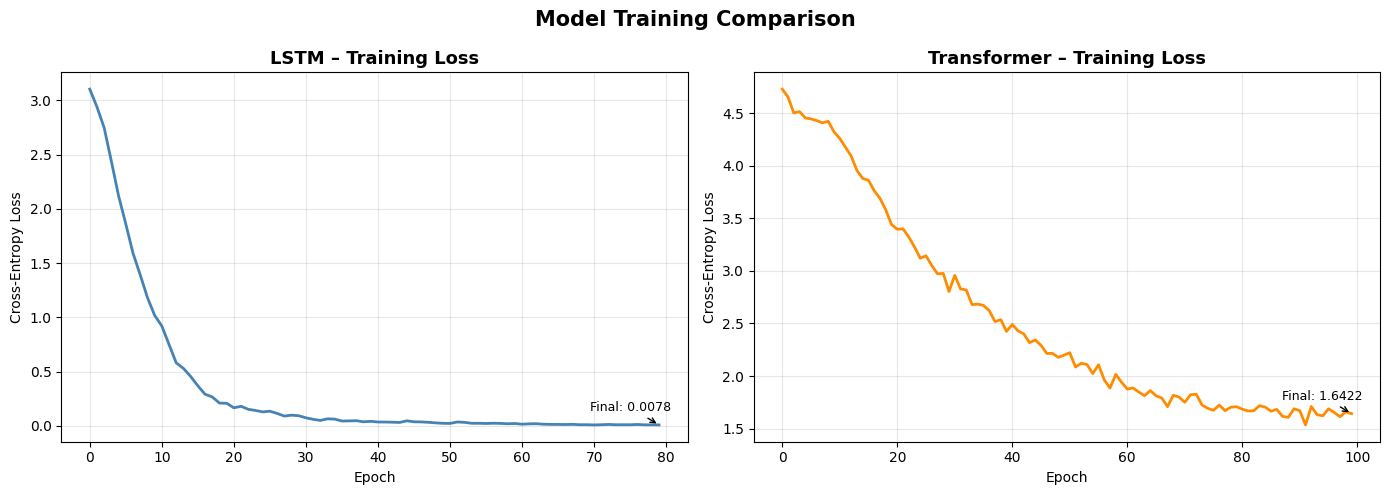


═════════════════════════════════════════════════════════════════
             📊 MODEL COMPARISON SUMMARY
═════════════════════════════════════════════════════════════════
Metric                                       LSTM   Transformer
-----------------------------------------------------------------
Tokenization                            Character          Word
Vocabulary Size                                28            85
Sequence Length                                40             8
Training Epochs                                80           100
Trainable Parameters                      865,052       160,917
Final Training Loss                        0.0078        1.6422
═════════════════════════════════════════════════════════════════


In [16]:
# ─── Side-by-side Loss Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_losses, color='steelblue', linewidth=2)
axes[0].set_title('LSTM – Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Final: {lstm_losses[-1]:.4f}',
                 xy=(len(lstm_losses)-1, lstm_losses[-1]),
                 xytext=(-50, 10), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

axes[1].plot(transformer_losses, color='darkorange', linewidth=2)
axes[1].set_title('Transformer – Training Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'Final: {transformer_losses[-1]:.4f}',
                 xy=(len(transformer_losses)-1, transformer_losses[-1]),
                 xytext=(-50, 10), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

plt.suptitle('Model Training Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Summary Table ───────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("             📊 MODEL COMPARISON SUMMARY")
print("═" * 65)
print(f"{'Metric':<35} {'LSTM':>13} {'Transformer':>13}")
print("-" * 65)
print(f"{'Tokenization':<35} {'Character':>13} {'Word':>13}")
print(f"{'Vocabulary Size':<35} {vocab_size:>13,} {vocab_size_t:>13,}")
print(f"{'Sequence Length':<35} {SEQ_LEN:>13} {SEQ_LEN_T:>13}")
print(f"{'Training Epochs':<35} {EPOCHS:>13} {EPOCHS_T:>13}")
print(f"{'Trainable Parameters':<35} {total_params:>13,} {total_params_t:>13,}")
print(f"{'Final Training Loss':<35} {lstm_losses[-1]:>13.4f} {transformer_losses[-1]:>13.4f}")
print("═" * 65)